In [1]:
# important libraries
import pandas as pd # for data manipulation
import numpy as np # for matrix
import matplotlib.pyplot as plt # to plot datas and samples

In [3]:
# Data have range between 0 to 255
train_data = pd.read_csv("dataset/mnist_test.csv") # 10,000 samples
test_data = pd.read_csv("dataset/mnist_train.csv") #  5,000 samples

In [4]:
Y_train = train_data.loc[:, 'label']
X_train = train_data.loc[:, train_data.columns != 'label']
Y_test = test_data.loc[:, 'label']
X_test = test_data.loc[:, test_data.columns != 'label']

X_train = X_train / 255 # make the pixels between 0 to 1 (0 -> pure black, 1 -> pure white)
X_test = X_test / 255

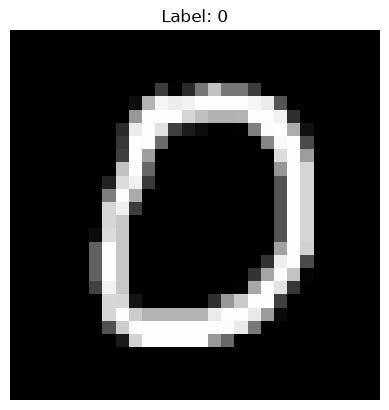

In [5]:
# View data

# ith position image in the data
i = 10
img = X_train.iloc[i].to_numpy().reshape(28, 28)
label = Y_train.iloc[i]

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(f"Label: {label}")
plt.show()

In [6]:
class Mnist:
    def __init__(self, layers, X_train, Y_train): 
        self.X = X_train.to_numpy().T  # Shape: (784, m)
        self.Y = Y_train.to_numpy()    # Shape: (m, 1)
        self.m = self.X.shape[1]       # Number of training examples
        self.layers = layers           # layers: [784, 10, 10]
        self.n = len(layers)           # len:    3

        # lists to hold parameters arrays
        self.W = []
        self.B = []
        
        # Cache structures for forward pass activations
        self.Z = [None] * (self.n - 1)
        self.A = [None] * self.n

        # Create one-hot matrix of shape (10, m)
        one_hot_Y_init = np.zeros((self.Y.size, self.layers[-1]))
        one_hot_Y_init[np.arange(self.Y.size), self.Y] = 1
        self.one_hot_Y = one_hot_Y_init.T

        # Initialize weights and biases of layers and put in lists
        for i in range(self.n - 1):
            w = np.random.randn(layers[i + 1], layers[i]) * np.sqrt(2.0 / layers[i])
            b = np.zeros((layers[i + 1], 1))
            self.W.append(w)
            self.B.append(b)

    # Using to eliminate negative numbers
    # R = {x, if x > 0
    #      0, otherwise
    def ReLU(self, Z):
        return np.maximum(Z, 0)

    # R = {1, if x > 0
    #      0, otherwise
    def ReLU_deriv(self, Z):
        return Z > 0

    # softmax - using for last layer probabilistic distribution
    # s = e^(Z) / sum(e^(Z) ; where Z is the output layer
    def softmax(self, Z):
        exps = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return exps / np.sum(exps, axis=0, keepdims=True)

    def forward(self):
        self.A[0] = self.X
        
        for i in range(self.n - 1):
            self.Z[i] = self.W[i] @ self.A[i] + self.B[i]
            
            # Softmax for output layer, ReLU for hidden layers
            if i == (self.n - 2): # output layer
                self.A[i + 1] = self.softmax(self.Z[i]) # use softmax to distribute
            else: # hidden layers
                self.A[i + 1] = self.ReLU(self.Z[i]) # use ReLU

    def backprop(self):
        # Lists to keep gradients organized by layer
        dW = [None] * (self.n - 1)
        dB = [None] * (self.n - 1)
        
        # Loop backwards through the network layers
        for i in range(self.n - 2, -1, -1):
            if i == (self.n - 2):
                # Output layer gradient
                dZ = self.A[i + 1] - self.one_hot_Y
            else:
                # Hidden layers gradient tracking down from previous layer's dZ
                dZ = (self.W[i + 1].T @ dZ) * self.ReLU_deriv(self.Z[i])
            
            dW[i] = (1 / self.m) * (dZ @ self.A[i].T)
            dB[i] = (1 / self.m) * np.sum(dZ, axis=1, keepdims=True)

        return dW, dB
        
    def cost(self):
        return -np.mean(
            np.sum(
                self.one_hot_Y * np.log(self.A[-1] + 1e-8),
                axis=0
            )
        )
     
    def train(self, iterations=1000, lr=0.15, log_after=100):
        for i in range(iterations):
            # Forward
            self.forward()

            # Backpropagation
            dW, dB = self.backprop()

            # Update parameters
            for k in range(self.n - 1):
                
                self.W[k] -= lr * dW[k]
                self.B[k] -= lr * dB[k]

            if i % log_after == 0:
                print(f"Iteration: {i:4d} | Cost: {self.cost()}")

    def get_accuracy(self, predictions):
        return np.sum(predictions == self.Y) / self.Y.size

    def make_predictions(self):
        self.forward()
        return np.argmax(self.A[self.n - 1], axis=0)

    # external usable function
    def check_accuracy(self, X, Y):
        # handle conversion if Pandas DataFrame/Series are passed in
        if hasattr(X, "to_numpy"):
            X = X.to_numpy().T
        elif X.shape[0] != 784:
            X = X.T

        # forward pass
        A_temp = X
        for i in range(self.n - 1):
            Z_temp = self.W[i] @ A_temp + self.B[i]
        
            if i == (self.n - 2): # output layer
                A_temp = self.softmax(Z_temp)
            else:
                A_temp = self.ReLU(Z_temp)

        pred = np.argmax(A_temp, axis=0)
        y_arr = np.asarray(Y)
        return (np.sum(pred == y_arr) / y_arr.size) * 100

    def test_prediction(self, index):
        # Extract a single image (784, 1)
        current_image = self.X[:, index, None]
        
        original_X = self.X
        self.X = current_image
    
        prediction = self.make_predictions()[0]
        label = self.Y[index]
        
        self.X = original_X
        
        # Reshape to 28x28 pixels for plotting
        current_image = current_image.reshape((28, 28)) * 255
        plt.gray()
        plt.imshow(current_image, interpolation='nearest')
        plt.title(f"Prediction: {prediction}")
        plt.show()

In [35]:
# Train the model
mnist = Mnist([784, 10, 10, 10], X_train, Y_train)
mnist.train(iterations=1000, lr=0.2, log_after=100)

Iteration:    0 | Cost: 2.2946791173765764
Iteration:  100 | Cost: 0.5080158738338402
Iteration:  200 | Cost: 0.3236441914252588
Iteration:  300 | Cost: 0.2618351474123544
Iteration:  400 | Cost: 0.2303889205684065
Iteration:  500 | Cost: 0.2119715905269435
Iteration:  600 | Cost: 0.18175770447481168
Iteration:  700 | Cost: 0.16820484988204995
Iteration:  800 | Cost: 0.16572383907204039
Iteration:  900 | Cost: 0.14306288628653022


In [36]:
accuracy = mnist.check_accuracy(X_test.to_numpy().T, Y_test)
accuracy

np.float64(91.06333333333333)

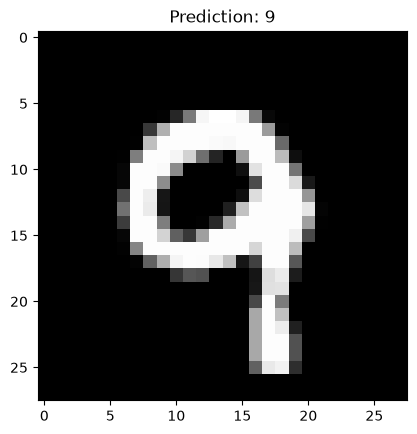

In [9]:
mnist.test_prediction(99)